In [220]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [221]:
df = pd.read_csv('car_fuel_efficiency_2026.csv')
df.head()

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0


In [222]:
# 1
df.isnull().sum()

model_year               0
origin                   0
fuel_type                0
drivetrain               0
num_doors                0
engine_displacement      0
num_cylinders            0
horsepower             877
vehicle_weight           0
acceleration           264
fuel_efficiency_mpg      0
dtype: int64

In [223]:
# 2
df['horsepower'].median()

np.float64(254.0)

In [224]:
df.columns

Index(['model_year', 'origin', 'fuel_type', 'drivetrain', 'num_doors',
       'engine_displacement', 'num_cylinders', 'horsepower', 'vehicle_weight',
       'acceleration', 'fuel_efficiency_mpg'],
      dtype='str')

In [225]:
df.dtypes

model_year               int64
origin                     str
fuel_type                  str
drivetrain                 str
num_doors                int64
engine_displacement      int64
num_cylinders            int64
horsepower             float64
vehicle_weight           int64
acceleration           float64
fuel_efficiency_mpg    float64
dtype: object

In [226]:
string_columns = list(df.dtypes[df.dtypes == 'str'].index)
string_columns

['origin', 'fuel_type', 'drivetrain']

In [227]:
for col in string_columns:
    df[col] = df[col].str.lower().str.replace(' ','_').str.replace('-','_')

df.head()

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,europe,gasoline,front_wheel_drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,europe,diesel,front_wheel_drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,asia,gasoline,front_wheel_drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,europe,gasoline,front_wheel_drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,usa,diesel,front_wheel_drive,3,2580,7,304.0,4510,17.5,31.0


In [228]:
for col in df.columns:
    print(col)
    print(df[col].unique()[:5])
    print(df[col].nunique)
    print()

model_year
[2006 2008 1996 1989 1994]
<bound method IndexOpsMixin.nunique of 0       2006
1       2008
2       1996
3       1989
4       1994
        ... 
9995    2005
9996    1993
9997    2014
9998    2004
9999    2011
Name: model_year, Length: 10000, dtype: int64>

origin
<StringArray>
['europe', 'asia', 'usa']
Length: 3, dtype: str
<bound method IndexOpsMixin.nunique of 0       europe
1       europe
2         asia
3       europe
4          usa
         ...  
9995       usa
9996      asia
9997       usa
9998       usa
9999       usa
Name: origin, Length: 10000, dtype: str>

fuel_type
<StringArray>
['gasoline', 'diesel', 'hybrid']
Length: 3, dtype: str
<bound method IndexOpsMixin.nunique of 0       gasoline
1         diesel
2       gasoline
3       gasoline
4         diesel
          ...   
9995    gasoline
9996    gasoline
9997    gasoline
9998      hybrid
9999      diesel
Name: fuel_type, Length: 10000, dtype: str>

drivetrain
<StringArray>
['front_wheel_drive', 'rear_wheel_drive', 

In [229]:
%matplotlib inline

<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

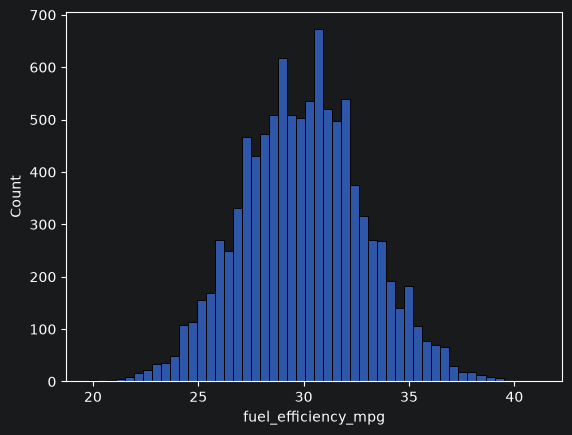

In [230]:
sns.histplot(df.fuel_efficiency_mpg, bins=50)

In [231]:
n = len(df)
n_val = n_test = int(n * 0.2)
n_train = n - n_val - n_test
n_val, n_test, n_train, n

(2000, 2000, 6000, 10000)

In [232]:
np.random.seed(42)

idx = np.arange(n)
np.random.shuffle(idx)

In [233]:
df_test = df.iloc[idx[:n_test]]
df_val = df.iloc[idx[n_val:n_val+n_test]]
df_train = df.iloc[idx[n_val+n_test:]]

In [234]:
df_test = df_test.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_train = df_train.reset_index(drop=True)

In [235]:
y_train = df_train.fuel_efficiency_mpg
y_test = df_test.fuel_efficiency_mpg
y_val = df_val.fuel_efficiency_mpg

del df_train['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']

In [236]:
def train_linear_regression(x,y):
    ones = np.ones(x.shape[0])
    x = np.column_stack([ones, x])

    XTX = x.T.dot(x)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(x.T).dot(y)

    return w_full[0], w_full[1:]


In [237]:
base = list(df_train.dtypes[df_train.dtypes != 'str'].index)
base

['model_year',
 'num_doors',
 'engine_displacement',
 'num_cylinders',
 'horsepower',
 'vehicle_weight',
 'acceleration']

In [238]:
df_train_clean_0 = df_train[base].copy()

df_train_clean_0['horsepower'] = df_train_clean_0['horsepower'].fillna(0)
df_train_clean_0['acceleration'] = df_train_clean_0['acceleration'].fillna(0)

#Replace the Nas with 0
x_train_0 = df_train_clean_0.values
x_train_0


array([[1.997e+03, 4.000e+00, 2.090e+03, ..., 2.220e+02, 4.110e+03,
        1.720e+01],
       [2.019e+03, 5.000e+00, 2.420e+03, ..., 2.720e+02, 4.530e+03,
        1.680e+01],
       [2.022e+03, 2.000e+00, 2.500e+03, ..., 2.630e+02, 4.110e+03,
        1.860e+01],
       ...,
       [2.013e+03, 3.000e+00, 2.430e+03, ..., 2.460e+02, 4.660e+03,
        1.940e+01],
       [2.014e+03, 4.000e+00, 2.450e+03, ..., 3.070e+02, 4.500e+03,
        1.910e+01],
       [1.997e+03, 2.000e+00, 2.060e+03, ..., 2.730e+02, 3.960e+03,
        1.950e+01]], shape=(6000, 7))

In [239]:
df_train_clean_mean = df_train[base].copy()

df_train_clean_mean['horsepower'] = df_train_clean_mean['horsepower'].fillna(df_train_clean_mean['horsepower'].mean())
df_train_clean_mean['acceleration'] = df_train_clean_mean['acceleration'].fillna(0)

#Replace with mean
x_train_mean = df_train_clean_mean.values
x_train_mean

array([[1.997e+03, 4.000e+00, 2.090e+03, ..., 2.220e+02, 4.110e+03,
        1.720e+01],
       [2.019e+03, 5.000e+00, 2.420e+03, ..., 2.720e+02, 4.530e+03,
        1.680e+01],
       [2.022e+03, 2.000e+00, 2.500e+03, ..., 2.630e+02, 4.110e+03,
        1.860e+01],
       ...,
       [2.013e+03, 3.000e+00, 2.430e+03, ..., 2.460e+02, 4.660e+03,
        1.940e+01],
       [2.014e+03, 4.000e+00, 2.450e+03, ..., 3.070e+02, 4.500e+03,
        1.910e+01],
       [1.997e+03, 2.000e+00, 2.060e+03, ..., 2.730e+02, 3.960e+03,
        1.950e+01]], shape=(6000, 7))

In [240]:
w0, w = train_linear_regression(x_train_0, y_train)
w0

np.float64(-153.32124444796082)

In [241]:
w0_mean, w_mean = train_linear_regression(x_train_mean, y_train)
w0_mean

np.float64(-151.7183779922123)

In [242]:
df_val_clean_0 = df_val[base].copy()
df_val_clean_mean = df_val[base].copy()

df_val_clean_0['horsepower'] = df_val_clean_0['horsepower'].fillna(0)
df_val_clean_0['acceleration'] = df_val_clean_0['acceleration'].fillna(0)

df_val_clean_mean['horsepower'] = df_val_clean_mean['horsepower'].fillna(df_val_clean_mean['horsepower'].mean())
df_val_clean_mean['acceleration'] = df_val_clean_mean['acceleration'].fillna(0)

#Replace the Nas with 0
x_val_0 = df_val_clean_0.values
x_val_mean = df_val_clean_mean.values

In [243]:
y_pred = w0 + x_val_0.dot(w)
y_pred

array([31.13101606, 30.3647653 , 35.16339782, ..., 26.44701577,
       29.30872379, 30.4100011 ], shape=(2000,))

In [244]:
y_mean_pred = w0_mean + x_val_mean.dot(w_mean)
y_mean_pred

array([30.90877041, 30.39397461, 35.19872973, ..., 26.56266199,
       29.33599089, 30.46614688], shape=(2000,))

In [245]:
def rmse(y, y_pred):
    se = (y - y_pred) ** 2
    mse = np.mean(se)
    return np.sqrt(mse)

In [246]:
# RMSE with NaN replaced by 0
round(rmse(y_val, y_pred),3)

np.float64(2.211)

In [247]:
# RMSE with NaN replaced by mean
round(rmse(y_val, y_mean_pred),3)

np.float64(2.205)

In [248]:
def train_linear_regression_reg(x,y,r):
    ones = np.ones(x.shape[0])
    x = np.column_stack([ones,x])
    XTX = x.T.dot(x)

    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(x.T).dot(y)

    return w_full[0], w_full[1:]

In [249]:
def compute_rmse(y, y_pred):
    se = (y - y_pred) ** 2
    mse = np.mean(se)
    return np.sqrt(mse)

r_list = [0, 0.01, 0.1, 1, 5, 10, 100]
rmse_dict = {}
for r in r_list:
    w0_reg, w_reg = train_linear_regression_reg(x_train_0, y_train, r)
    y_pred_reg = w0_reg + x_val_0.dot(w_reg)
    rmse_val = round(compute_rmse(y_val, y_pred_reg), 4)
    rmse_dict[r] = rmse_val

In [250]:
for r, rmse in rmse_dict.items():
    print(f"Regularization : {r} | RMSE : {rmse}")

Regularization : 0 | RMSE : 2.2113
Regularization : 0.01 | RMSE : 2.2105
Regularization : 0.1 | RMSE : 2.2214
Regularization : 1 | RMSE : 2.3343
Regularization : 5 | RMSE : 2.3912
Regularization : 10 | RMSE : 2.4008
Regularization : 100 | RMSE : 2.4101


In [261]:
#5
def prepare_data(df_, seed_list, base_):

    n_ = len(df)
    n_val_ = n_test_ = int(n_ * 0.2)
    n_train_ = n_ - n_val_ - n_test_

    score = {}
    score_train = []
    score_val = []
    score_test = []
    for s in seed_list:
        np.random.seed(s)

        idx_ = np.arange(n_)
        np.random.shuffle(idx_)

        df_train_ = df_.iloc[idx_[:n_train_]]
        df_val_   = df_.iloc[idx_[n_train_:n_train_ + n_val_]]
        df_test_  = df_.iloc[idx_[n_train_ + n_val_:]]

        df_test_ = df_test_.reset_index(drop=True)
        df_val_ = df_val_.reset_index(drop=True)
        df_train_ = df_train_.reset_index(drop=True)

        y_train_ = df_train_.fuel_efficiency_mpg
        y_test_ = df_test_.fuel_efficiency_mpg
        y_val_ = df_val_.fuel_efficiency_mpg

        del df_train_['fuel_efficiency_mpg']
        del df_test_['fuel_efficiency_mpg']
        del df_val_['fuel_efficiency_mpg']

        df_train_clean = df_train_[base_].copy()
        df_val_clean = df_val_[base_].copy()
        df_test_clean = df_test_[base_].copy()

        df_train_clean['horsepower'] = df_train_clean['horsepower'].fillna(0)
        df_train_clean['acceleration'] = df_train_clean['acceleration'].fillna(0)
        df_val_clean['horsepower'] = df_val_clean['horsepower'].fillna(0)
        df_val_clean['acceleration'] = df_val_clean['acceleration'].fillna(0)
        df_test_clean['horsepower'] = df_test_clean['horsepower'].fillna(0)
        df_test_clean['acceleration'] = df_test_clean['acceleration'].fillna(0)

        #Replace the Nas with 0
        x_train_ = df_train_clean.values
        x_val_ = df_val_clean.values
        x_test_ = df_test_clean.values

        w0_, w_ = train_linear_regression(x_train_, y_train_)

        y_pred_train = w0_ + x_train_.dot(w_)
        y_pred_val = w0_ + x_val_.dot(w_)
        y_pred_test = w0_ + x_test_.dot(w_)

        score_train.append(compute_rmse(y_train_, y_pred_train))
        score_val.append(compute_rmse(y_val_, y_pred_val))
        score_test.append(compute_rmse(y_test_, y_pred_test))

    score['train'] = score_train
    score['val'] = score_val
    score['test'] = score_test

    return score


In [262]:
def traing_full():
    seed_list = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
    base_f = list(df_train.dtypes[df_train.dtypes != 'str'].index)
    score = prepare_data(df, seed_list, base_f)

    std_train = np.std(score['train'])
    std_val = np.std(score['val'])
    std_test = np.std(score['test'])

    return f"std train : {round(std_train,3)} | std val : {round(std_val,3)} | std test : {round(std_test,3)}"

traing_full()

'std train : 0.013 | std val : 0.031 | std test : 0.016'